In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [9]:

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (506, 14)

First 5 rows:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [10]:
print("Dataset Info:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nTarget variable (MEDV) stats:")
print(df['medv'].describe())

print("\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Dataset Info:
Rows: 506, Columns: 14

Target variable (MEDV) stats:
count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: medv, dtype: float64

Missing values (top 10):
crim     0
zn       0
indus    0
chas     0
nox      0
rm       0
age      0
dis      0
rad      0
tax      0
dtype: int64


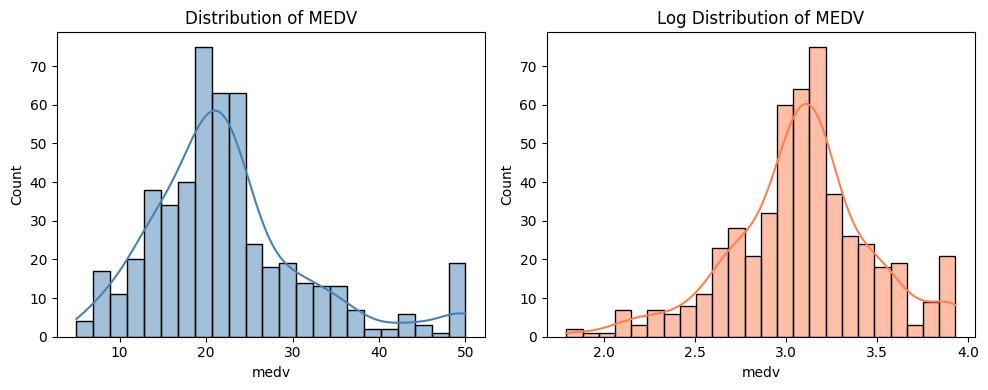

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['medv'], kde=True, color='steelblue')
plt.title('Distribution of MEDV')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['medv']), kde=True, color='coral')
plt.title('Log Distribution of MEDV')

plt.tight_layout()
plt.show()

In [13]:
# Correlation of numeric columns with SalePrice
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['medv'].sort_values(ascending=False)

print("Top 10 features correlated with SalePrice:")
print(corr.head(11))

Top 10 features correlated with SalePrice:
medv    1.000000
rm      0.695360
zn      0.360445
b       0.333461
dis     0.249929
chas    0.175260
age    -0.376955
rad    -0.381626
crim   -0.388305
nox    -0.427321
tax    -0.468536
Name: medv, dtype: float64


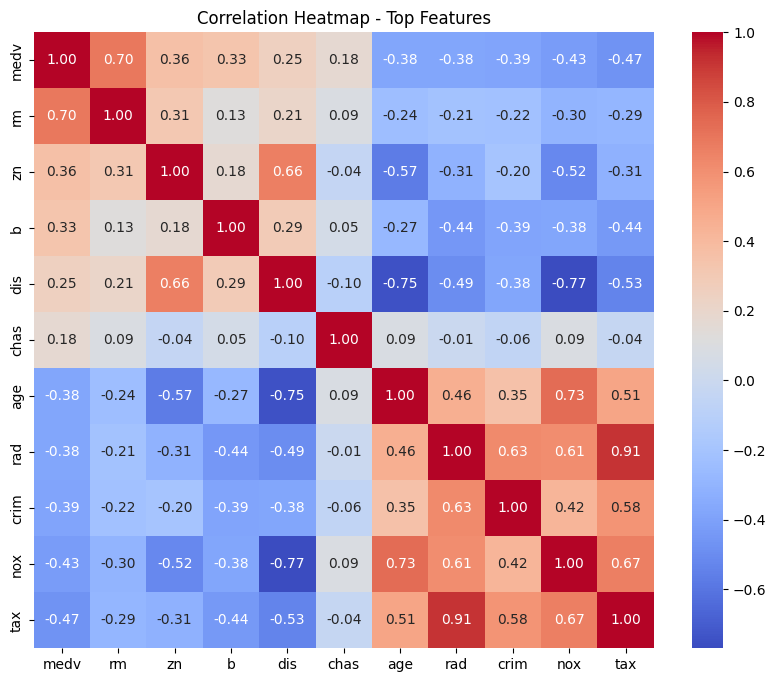

In [14]:
top_features = corr.head(11).index
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top Features')
plt.show()

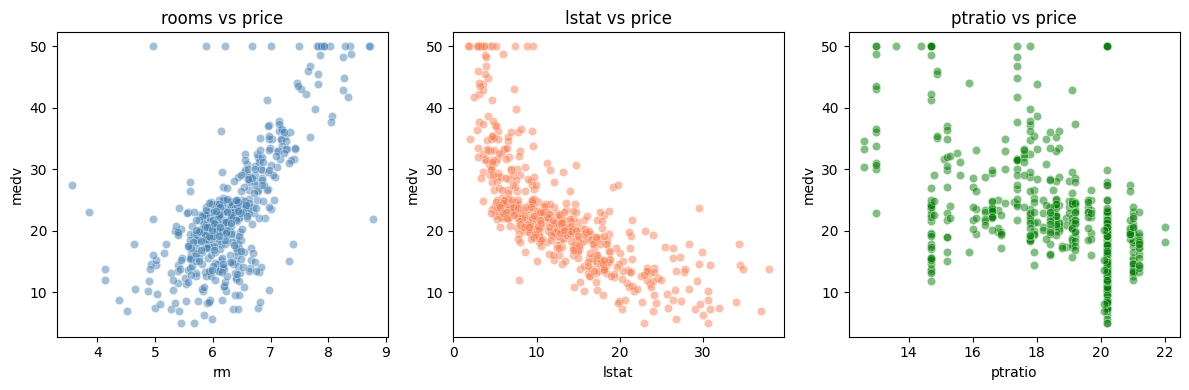

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.scatterplot(x=df['rm'], y=df['medv'], alpha=0.5, color='steelblue')
plt.title('rooms vs price')

plt.subplot(1,3,2)
sns.scatterplot(x=df['lstat'], y=df['medv'], alpha=0.5, color='coral')
plt.title('lstat vs price')

plt.subplot(1,3,3)
sns.scatterplot(x=df['ptratio'], y=df['medv'], alpha=0.5, color='green')
plt.title('ptratio vs price')

plt.tight_layout()
plt.show()

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# numeric
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# categorical (only if present)
if len(categorical_cols) > 0:
    df[categorical_cols] = df[categorical_cols].fillna(
        df[categorical_cols].mode().iloc[0]
    )

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [21]:
before = df.shape[0]

df = df[df['rm'] < 8]   # remove extreme large houses (too many rooms)

after = df.shape[0]

print(f"removed {before - after} outliers from rm")
print(f"dataset size: {before} → {after}")

removed 13 outliers from rm
dataset size: 506 → 493


In [22]:
# feature engineering for boston dataset

df['rooms_per_tax'] = df['rm'] / df['tax']
df['age_squared'] = df['age'] ** 2
df['lstat_rm_ratio'] = df['lstat'] / df['rm']
df['is_old'] = (df['age'] > 50).astype(int)

print("new features created:")
print("✅ rooms_per_tax")
print("✅ age_squared")
print("✅ lstat_rm_ratio")
print("✅ is_old")

new features created:
✅ rooms_per_tax
✅ age_squared
✅ lstat_rm_ratio
✅ is_old


In [23]:
# target
y = np.log1p(df['medv'])

# features
features = ['rm', 'lstat', 'ptratio', 'tax', 'dis', 'crim']

X = df[features]

print(f"features: {X.shape}")
print(f"target: {y.shape}")

features: (493, 6)
target: (493,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print("✅ Data split done! (80% train, 20% test)")

Training set: (394, 6)
Testing set: (99, 6)
✅ Data split done! (80% train, 20% test)


In [25]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("✅ Both models trained!")

✅ Both models trained!


In [26]:
def evaluate(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  R² Score : {r2:.4f} ({r2*100:.1f}% variance explained)")
    print(f"  RMSE     : {rmse:.4f}")
    print()

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

Linear Regression:
  R² Score : 0.7039 (70.4% variance explained)
  RMSE     : 0.1907

Random Forest:
  R² Score : 0.8239 (82.4% variance explained)
  RMSE     : 0.1471



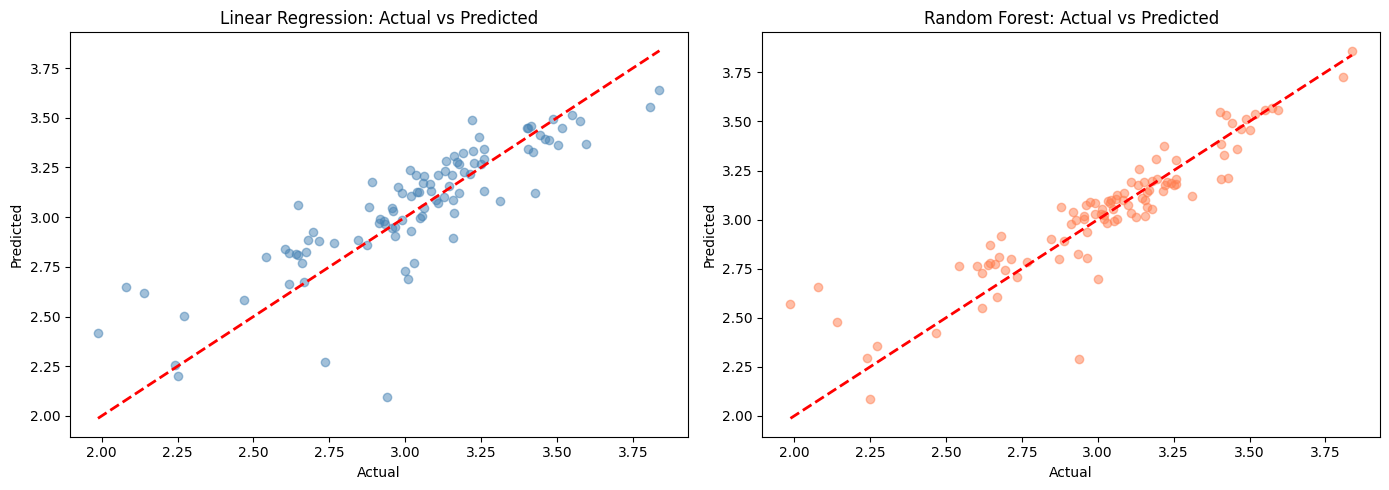

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, lr_pred, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# Random Forest
axes[1].scatter(y_test, rf_pred, alpha=0.5, color='coral')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

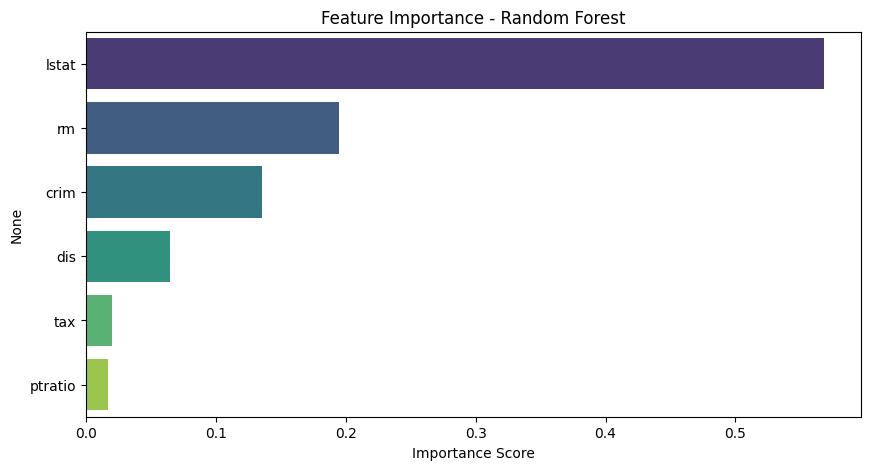

Top 3 most important features:
lstat    0.568164
rm       0.195160
crim     0.135265
dtype: float64


In [28]:
feat_imp = pd.Series(rf.feature_importances_, index=features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

print("Top 3 most important features:")
print(feat_imp.head(3))